In [ ]:
# Import required libraries
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.metrics import root_mean_squared_error,mean_absolute_error,r2_score,roc_auc_score
from xgboost import XGBRegressor

In [ ]:
# We will be use the AmesHousing Dataset for our practice.
df = pd.read_csv('AmesHousing.csv')
df.set_index('Order',inplace=True) # As this dataset had an order column , I thought we could use it as index .

In [ ]:
df.head()
# Inspecting the head :
'''
Analysis : Lot of columns , too many to deal with at once ; further must devise strategies to handle with ease.
'''

,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
Order,,,,,,,,,,,,,,,,,,,,,
1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [ ]:
df.tail() # Check the tail too

,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
Order,,,,,,,,,,,,,,,,,,,,,
2926,923275080,80,RL,37.0,7937,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,GdPrv,NaN,0,3,2006,WD,Normal,142500
2927,923276100,20,RL,NaN,8885,Pave,NaN,IR1,Low,AllPub,...,0,NaN,MnPrv,NaN,0,6,2006,WD,Normal,131000
2928,923400125,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal,132000
2929,924100070,20,RL,77.0,10010,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2006,WD,Normal,170000
2930,924151050,60,RL,74.0,9627,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,11,2006,WD,Normal,188000


In [ ]:
df.columns # As we can see these are the names of columns (oo many) ; judging by the names and some research
# I found out that the columns are basically information of the housing properties and basically they describe the features 
# found in them. Later I found something more..

Index(['PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area', 'Street',
       'Alley', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config',
       'Land Slope', 'Neighborhood', 'Condition 1', 'Condition 2', 'Bldg Type',
       'House Style', 'Overall Qual', 'Overall Cond', 'Year Built',
       'Year Remod/Add', 'Roof Style', 'Roof Matl', 'Exterior 1st',
       'Exterior 2nd', 'Mas Vnr Type', 'Mas Vnr Area', 'Exter Qual',
       'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure',
       'BsmtFin Type 1', 'BsmtFin SF 1', 'BsmtFin Type 2', 'BsmtFin SF 2',
       'Bsmt Unf SF', 'Total Bsmt SF', 'Heating', 'Heating QC', 'Central Air',
       'Electrical', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF',
       'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath',
       'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'Kitchen Qual',
       'TotRms AbvGrd', 'Functional', 'Fireplaces', 'Fireplace Qu',
       'Garage Type', 'Garage Yr Blt', 'Garage Finish'

In [ ]:
df.info() 
# Used the information to understand the dtypes and non null count to get an idea of the dataset and amount of preprocessing required.

<class 'pandas.core.frame.DataFrame'>
Index: 2930 entries, 1 to 2930
Data columns (total 81 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PID              2930 non-null   int64  
 1   MS SubClass      2930 non-null   int64  
 2   MS Zoning        2930 non-null   object 
 3   Lot Frontage     2440 non-null   float64
 4   Lot Area         2930 non-null   int64  
 5   Street           2930 non-null   object 
 6   Alley            198 non-null    object 
 7   Lot Shape        2930 non-null   object 
 8   Land Contour     2930 non-null   object 
 9   Utilities        2930 non-null   object 
 10  Lot Config       2930 non-null   object 
 11  Land Slope       2930 non-null   object 
 12  Neighborhood     2930 non-null   object 
 13  Condition 1      2930 non-null   object 
 14  Condition 2      2930 non-null   object 
 15  Bldg Type        2930 non-null   object 
 16  House Style      2930 non-null   object 
 17  Overall Qual     29

In [ ]:
# As we found out that there are many columns of different dtypes , it is better to split them and further proceed differently.
# Still after splitting there maybe a lot of problems that need to be addressed later.

columns_object = df.select_dtypes(include='object') # All the columns are objects and there is no hidden numeric type hidden
# One thing is confirmed that there certainly cant be any differnt types morphedn in below columns , the only fishy columns are 
# the object columns .
columns_int = df.select_dtypes(include='int') 
columns_float = df.select_dtypes(include='float')

In [62]:
# A simple for loop to check for hidden numeric values in columns_object
for x in columns_object.columns:
    print(f' Column {x} : \n {columns_object[x].unique()} \n ')

 Column MS Zoning : 
 ['RL' 'RH' 'FV' 'RM' 'C (all)' 'I (all)' 'A (agr)'] 
 
 Column Street : 
 ['Pave' 'Grvl'] 
 
 Column Alley : 
 [nan 'Pave' 'Grvl'] 
 
 Column Lot Shape : 
 ['IR1' 'Reg' 'IR2' 'IR3'] 
 
 Column Land Contour : 
 ['Lvl' 'HLS' 'Bnk' 'Low'] 
 
 Column Utilities : 
 ['AllPub' 'NoSewr' 'NoSeWa'] 
 
 Column Lot Config : 
 ['Corner' 'Inside' 'CulDSac' 'FR2' 'FR3'] 
 
 Column Land Slope : 
 ['Gtl' 'Mod' 'Sev'] 
 
 Column Neighborhood : 
 ['NAmes' 'Gilbert' 'StoneBr' 'NWAmes' 'Somerst' 'BrDale' 'NPkVill'
 'NridgHt' 'Blmngtn' 'NoRidge' 'SawyerW' 'Sawyer' 'Greens' 'BrkSide'
 'OldTown' 'IDOTRR' 'ClearCr' 'SWISU' 'Edwards' 'CollgCr' 'Crawfor'
 'Blueste' 'Mitchel' 'Timber' 'MeadowV' 'Veenker' 'GrnHill' 'Landmrk'] 
 
 Column Condition 1 : 
 ['Norm' 'Feedr' 'PosN' 'RRNe' 'RRAe' 'Artery' 'PosA' 'RRAn' 'RRNn'] 
 
 Column Condition 2 : 
 ['Norm' 'Feedr' 'PosA' 'PosN' 'Artery' 'RRNn' 'RRAe' 'RRAn'] 
 
 Column Bldg Type : 
 ['1Fam' 'TwnhsE' 'Twnhs' 'Duplex' '2fmCon'] 
 
 Column House St

In [ ]:
# Check the number of columns in each group
columns_object.shape[1] , columns_int.shape[1] , columns_float.shape[1]

(43, 27, 11)

In [ ]:
# This step was necessary as I wanted to make sure that there are no different dtype columns.
columns_object.shape[1] + columns_int.shape[1] + columns_float.shape[1] == df.shape[1]

True

In [ ]:
# The description of the numeric columns , altough a better visualization of corrrelation between variables' is needed at this point.
df.describe()

,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2.930000e+03,2930.000000,2440.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2907.000000,2929.000000,...,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,7.144645e+08,57.387372,69.224590,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.896801,442.629566,...,93.751877,47.533447,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068
std,1.887308e+08,42.638025,23.365335,7880.017759,1.411026,1.111537,30.245361,20.860286,179.112611,455.590839,...,126.361562,67.483400,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357
min,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,5.284770e+08,20.000000,58.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,5.354536e+08,50.000000,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,370.000000,...,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,9.071811e+08,70.000000,80.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,164.000000,734.000000,...,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000
max,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


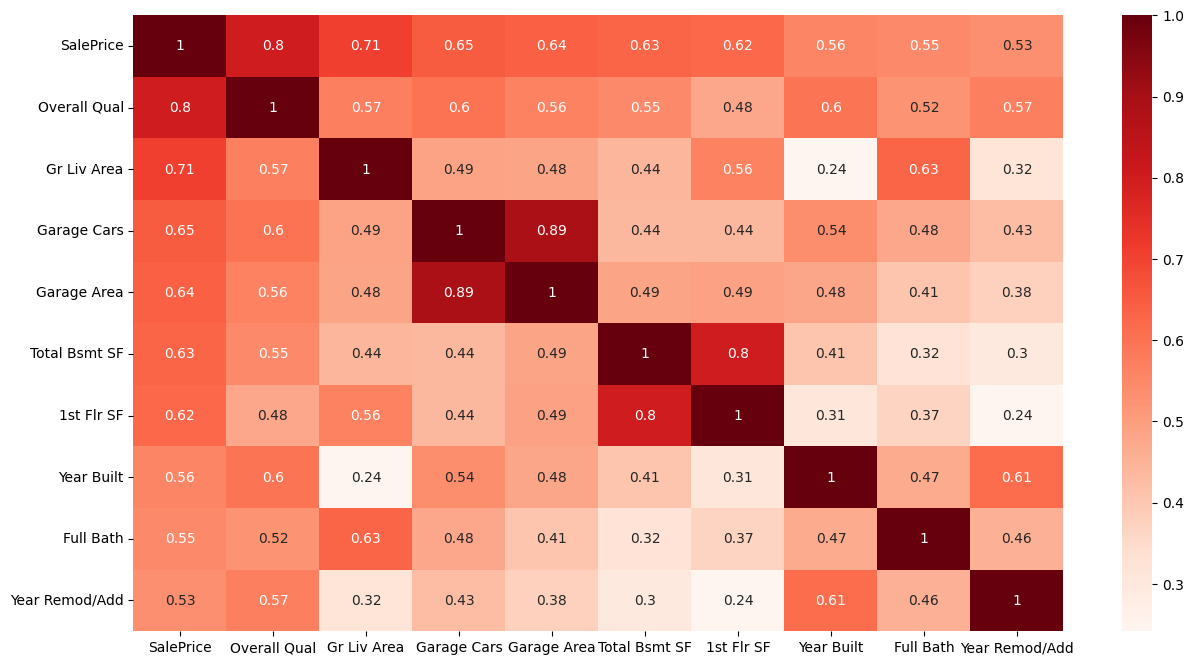

In [ ]:
# To better visualize which columns contribute the SalePrice column the most we will draw a heatmap
# where we will use the top10 most correlated values to SalePrice.
plt.figure(figsize=(15,8))
top_corr = df.corr(numeric_only=True)['SalePrice'].sort_values(ascending=False).head(10)
sns.heatmap(    
                df[top_corr.index].corr(),
                annot=True,
                cmap = 'Reds'
    )
plt.show()

In [ ]:
# Basically a SIMPLE LOOP where  a list of columns that have any of the values missing is appended to the list.
missing_value_columns = []
for x in df.columns:
    if df[x].isna().sum() != 0:
        missing_value_columns.append(x)

In [ ]:
# I will be using the missingno library to better evaluate and analyze the trends found in missing columns
import missingno as msno

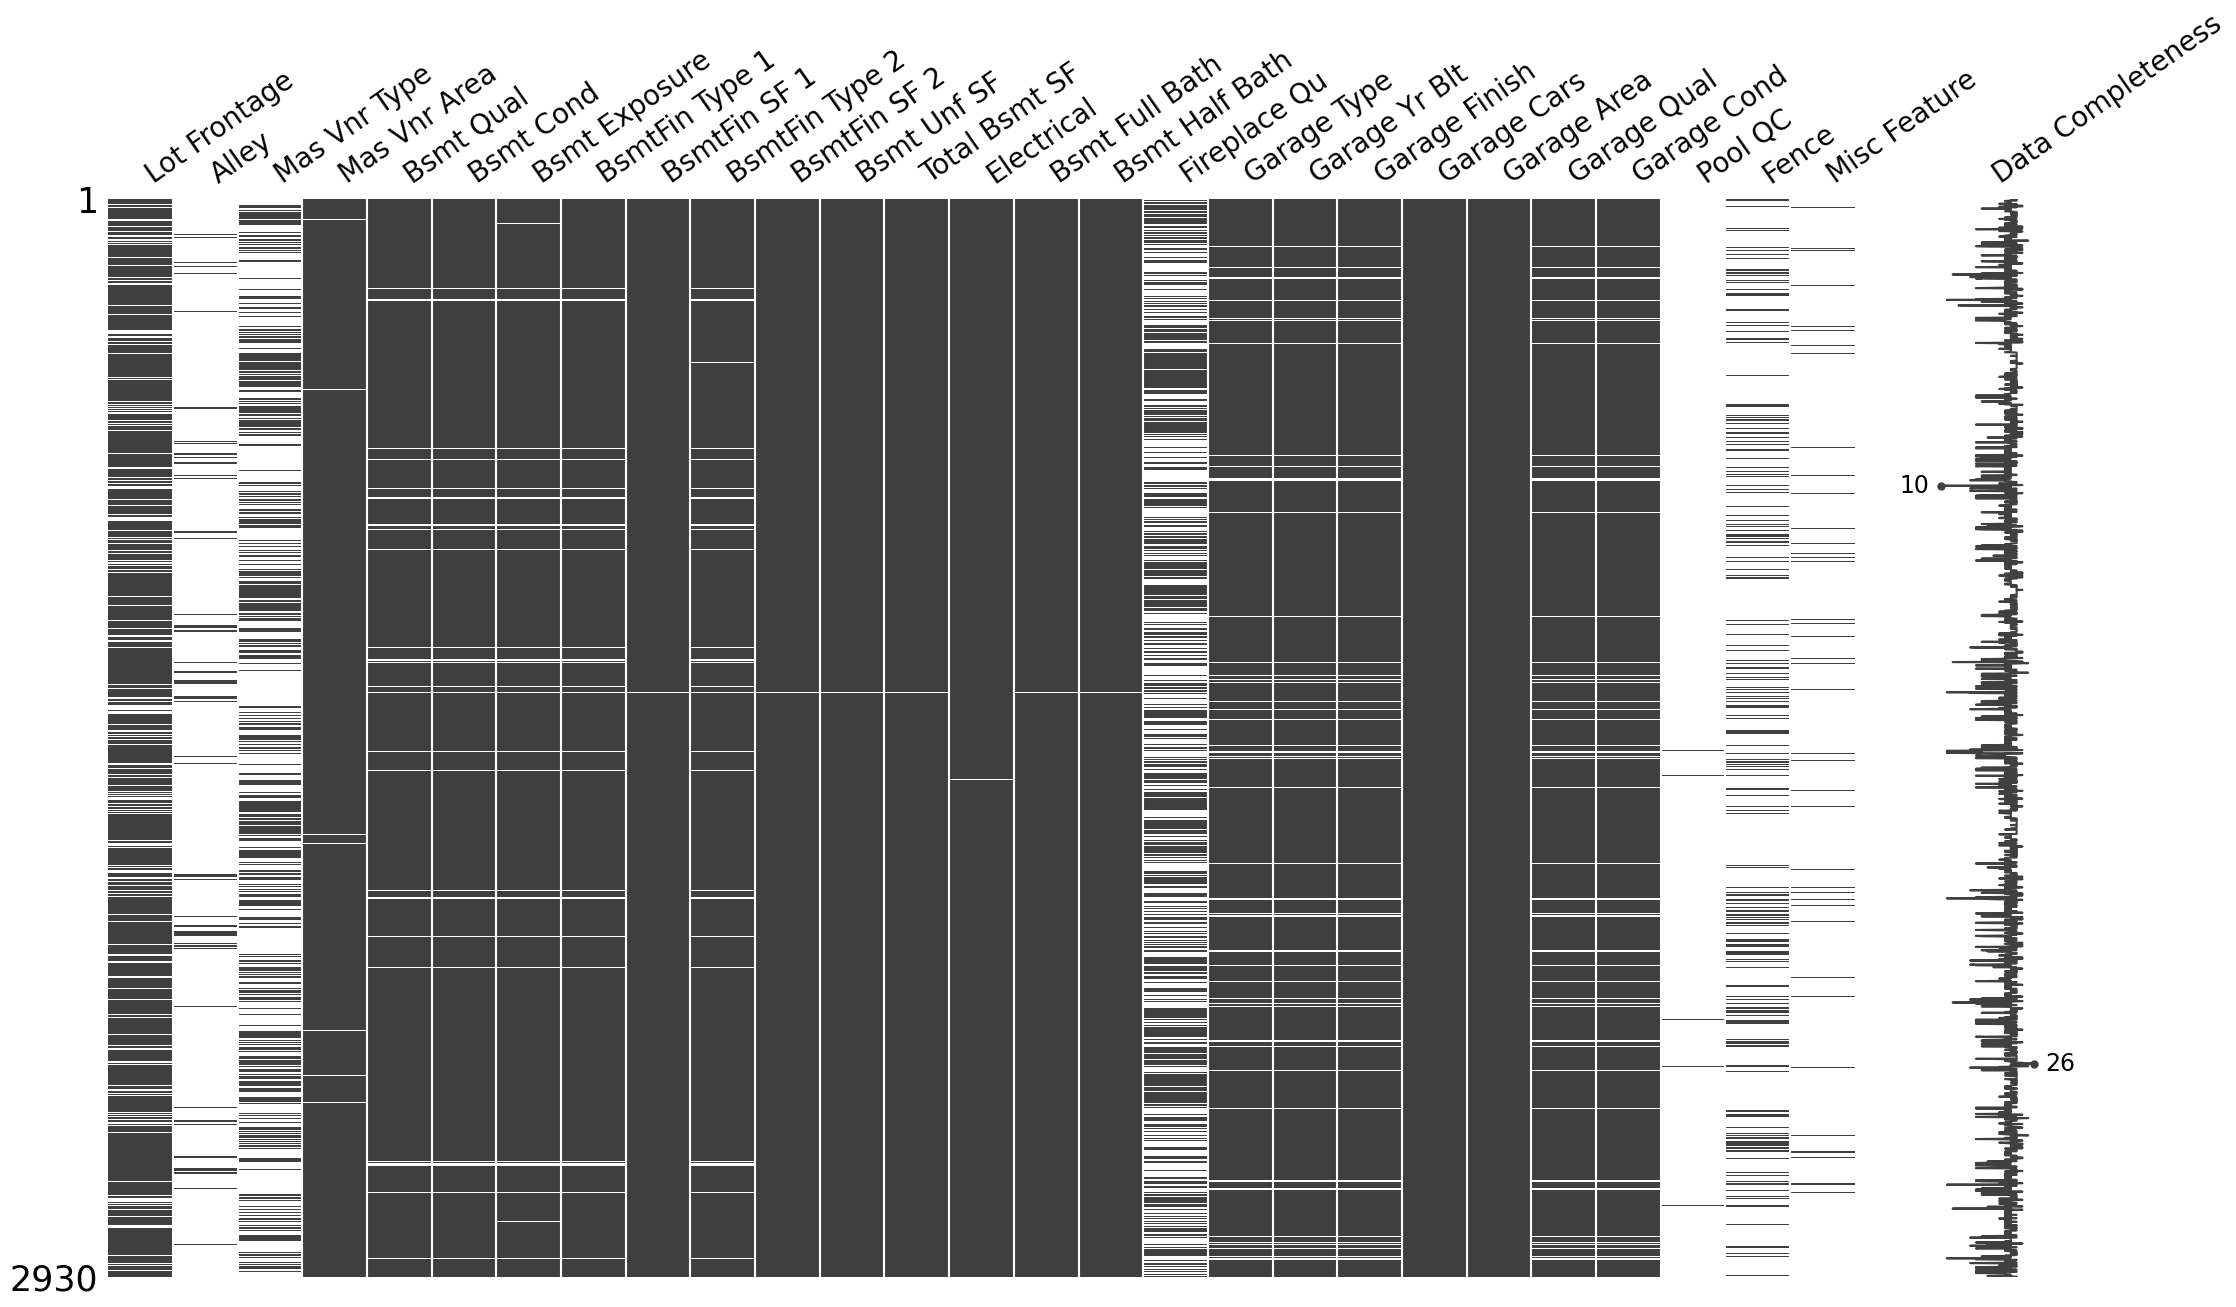

In [ ]:
msno.matrix(
                df = df[missing_value_columns], # Original dataset
                figsize=(25,14),
                fontsize = 20,
                label_rotation = 35,
                labels=True
)
'''
    Found out that there is a trend in bsmnt and mas vnr area, garage features .
    What does this mean ? - I think these are some houses where they dont have garages and basements to begin with ,
    and for many other features there is a pattern found depitcting the missingness.
    There maybe other reasons too for which the columns might be missing which may be founf during outlier analysis 
'''
plt.show()

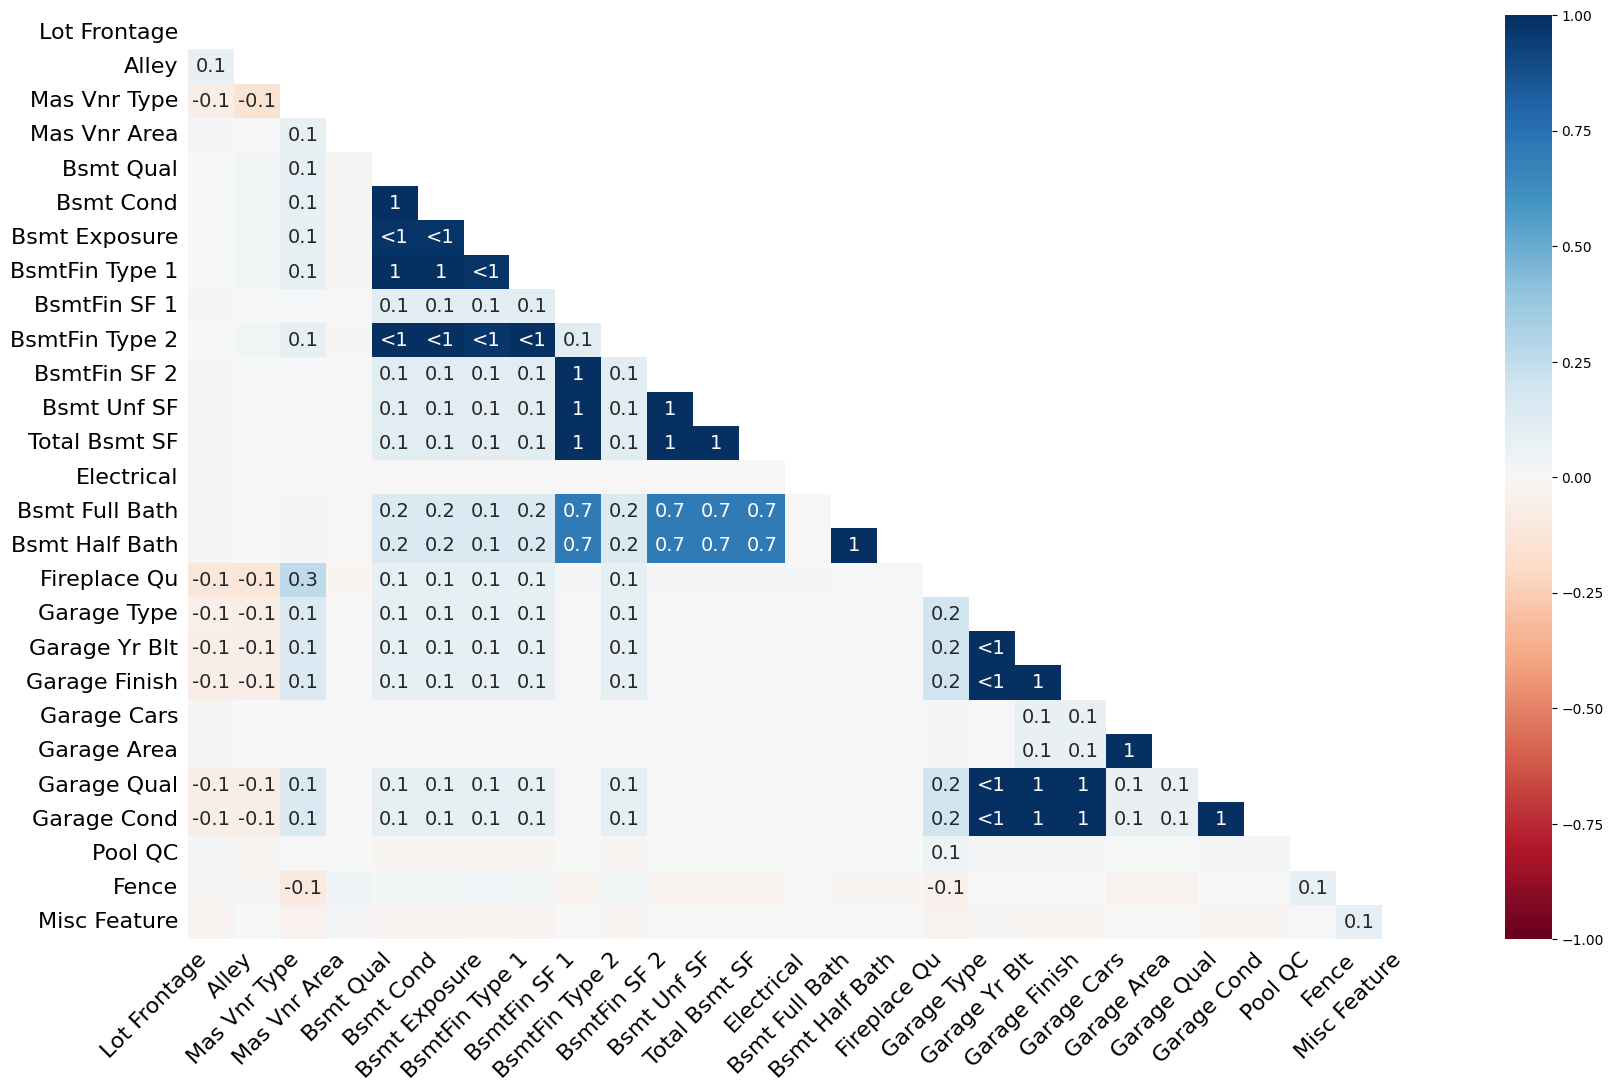

In [ ]:
# A heatmap is use to check whether the missingness of a column influences other features
# Similar observations found as above
msno.heatmap(
                df = df[missing_value_columns]
)
plt.show()

In [ ]:
# I created a dataframe to check the amount of missingness in values for each column
# The values were converted to percentage for better evaluation
percentage_missing_values_in_columns = pd.DataFrame({
    'columns'             : missing_value_columns,
    'percentage_missing'  :  ((df[missing_value_columns].isna().sum()/df.shape[0]*100).values)
}).sort_values(by='percentage_missing',ascending=False)

In [ ]:
percentage_missing_values_in_columns[:10] # The top 10 columns with the most quantity missing

,columns,percentage_missing
24,Pool QC,99.556314
26,Misc Feature,96.382253
1,Alley,93.242321
25,Fence,80.477816
2,Mas Vnr Type,60.580205
16,Fireplace Qu,48.532423
0,Lot Frontage,16.723549
22,Garage Qual,5.426621
23,Garage Cond,5.426621
18,Garage Yr Blt,5.426621


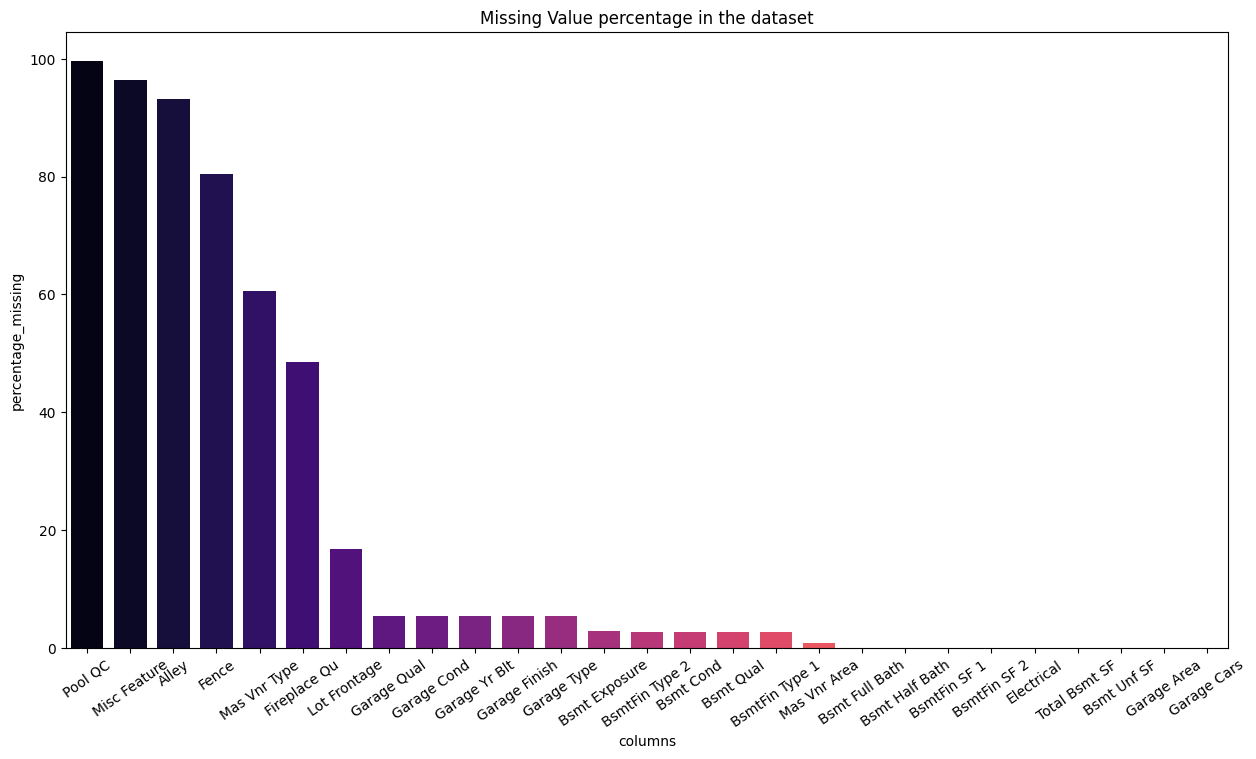

In [ ]:
# Basically a barplot created to analyze the percentage of values missing in each column
plt.figure(figsize=(15,8))
sns.barplot(
                data = percentage_missing_values_in_columns,
                x = 'columns',
                y = 'percentage_missing',
                hue = 'columns',
                palette='magma',
                width = 0.75,
                saturation = True
)
plt.title('Missing Value percentage in the dataset')
plt.xticks(rotation=35)
plt.show()
'''
At first like other ordinary datasets I was planning to  devise strategies for imputating these columns.
But then after some brainstorming and research turns out there can be missing values for this dataset -- Why ?
Because for example take the Pool Qc below ; the percent missing here do not mean that there was this much
human error , it simply means that these many percentage of houses do not have pool at their home -- So What ?
So we have to create a seperate placeholder / value to be imputed like : 'Missing' / 'None' to be added and then
further encode or map values otherwise our model trained will be really weak .
'''

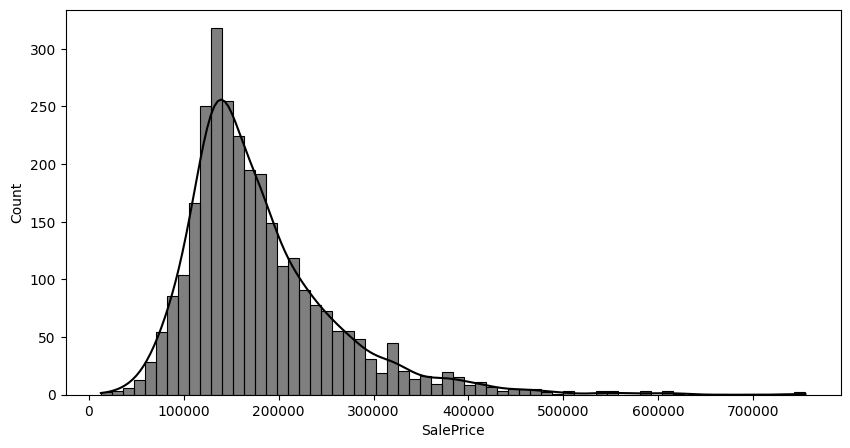

In [ ]:
# The SalePrice column here is right-skewed , this means we must make this normally distributed.
# Proposed future strategy : Log-Transformation
plt.figure(figsize=(10,5))
sns.histplot(
                data = df,
                x = 'SalePrice',
                color = 'black',
                kde = True,
)
plt.show()